In [1]:
# Model Comparison with Hyperparameters from CV Tuning
# This notebook trains and evaluates models using best hyperparameters found during cross-validation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load preprocessed data
data_path = '/Users/ronakpanchal/Desktop/College/ML/lab/Project/datasets/heart_preprocessed_scaled.csv'
data = pd.read_csv(data_path)

print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())

# Split features and target
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# Split the data (same random_state as CV notebooks)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training set:\n{y_train.value_counts()}")

Dataset shape: (918, 16)

First few rows:
        Age       Sex  RestingBP  Cholesterol  FastingBS     MaxHR  \
0 -1.433140  0.515952   0.410909     0.825070  -0.551341  1.382928   
1 -0.478484 -1.938163   1.491752    -0.171961  -0.551341  0.754157   
2 -1.751359  0.515952  -0.129513     0.770188  -0.551341 -1.525138   
3 -0.584556 -1.938163   0.302825     0.139040  -0.551341 -1.132156   
4  0.051881  0.515952   0.951331    -0.034755  -0.551341 -0.581981   

   ExerciseAngina   Oldpeak  ST_Slope  HeartDisease  ChestPain_ASY  \
0       -0.823556 -0.832432  1.052114             0       2.075177   
1       -0.823556  0.105664 -0.596078             1      -0.481887   
2       -0.823556 -0.832432  1.052114             0       2.075177   
3        1.214246  0.574711 -0.596078             1      -0.481887   
4       -0.823556 -0.832432  1.052114             0      -0.481887   

   ChestPain_ATA  ChestPain_NAP  ChestPain_TA  RestingECG_LVH  \
0      -0.532838      -0.229679     -0.507478      

In [3]:
# Best Hyperparameters from CV Tuning (extracted from cv_hyperparameter_tuned folder)

# Logistic Regression
# Best parameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear'}
print("Training Logistic Regression...")
log_reg_model = LogisticRegression(
    C=0.1, 
    max_iter=100, 
    penalty='l2', 
    random_state=42, 
    solver='liblinear'
)
log_reg_model.fit(X_train, y_train)
print("✓ Logistic Regression trained")

Training Logistic Regression...
✓ Logistic Regression trained


In [4]:
# Decision Tree
# Best parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 
#                   'min_samples_leaf': 5, 'min_samples_split': 2, 'random_state': 42}
print("Training Decision Tree...")
decision_tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    max_features=None,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42
)
decision_tree_model.fit(X_train, y_train)
print("✓ Decision Tree trained")

Training Decision Tree...
✓ Decision Tree trained


In [5]:
# Random Forest
# Best parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 10, 
#                   'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 
#                   'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
print("Training Random Forest...")
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    criterion='gini',
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=2,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
random_forest_model.fit(X_train, y_train)
print("✓ Random Forest trained")

Training Random Forest...
✓ Random Forest trained
✓ Random Forest trained


In [6]:
# K-Nearest Neighbors
# Best parameters: {'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 25, 'p': 1, 'weights': 'uniform'}
print("Training K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(
    n_neighbors=25,
    weights='uniform',
    metric='minkowski',
    p=1,
    leaf_size=20
)
knn_model.fit(X_train, y_train)
print("✓ KNN trained")

Training K-Nearest Neighbors...
✓ KNN trained


In [7]:
# Support Vector Classifier
# Best parameters: {'C': 1, 'class_weight': None, 'degree': 2, 'gamma': 0.01, 
#                   'kernel': 'rbf', 'probability': True, 'random_state': 42}
print("Training SVC...")
svc_model = SVC(
    C=1,
    kernel='rbf',
    gamma=0.01,
    degree=2,
    class_weight=None,
    probability=True,
    random_state=42
)
svc_model.fit(X_train, y_train)
print("✓ SVC trained")

Training SVC...
✓ SVC trained


In [8]:
# Gaussian Naive Bayes
# Best parameters: {'var_smoothing': 1.0}
print("Training Gaussian Naive Bayes...")
gaussian_nb_model = GaussianNB(var_smoothing=1.0)
gaussian_nb_model.fit(X_train, y_train)
print("✓ Gaussian NB trained")

Training Gaussian Naive Bayes...
✓ Gaussian NB trained


In [9]:
# LightGBM
# Best parameters: {'class_weight': None, 'colsample_bytree': 0.8, 'device': 'gpu', 
#                   'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 
#                   'n_estimators': 500, 'num_leaves': 31, 'random_state': 42, 
#                   'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8, 'verbose': -1}
print("Training LightGBM...")
lightgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=0,
    class_weight=None,
    random_state=42,
    verbose=-1,
    device='cpu'  # Changed from 'gpu' for compatibility
)
lightgbm_model.fit(X_train, y_train)
print("✓ LightGBM trained")

Training LightGBM...
✓ LightGBM trained
✓ LightGBM trained


In [10]:
# XGBoost
# Best parameters: {'colsample_bytree': 1.0, 'device': 'cuda', 'gamma': 0.1, 
#                   'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 
#                   'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 
#                   'scale_pos_weight': 3, 'subsample': 1.0, 'tree_method': 'hist'}
print("Training XGBoost...")
xgboost_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    gamma=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=3,
    tree_method='hist',
    random_state=42,
    device='cpu'  # Changed from 'cuda' for compatibility
)
xgboost_model.fit(X_train, y_train)
print("✓ XGBoost trained")

Training XGBoost...
✓ XGBoost trained
✓ XGBoost trained


In [11]:
# CatBoost
# Best parameters: {'bagging_temperature': 0, 'border_count': 64, 'depth': 6, 
#                   'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1, 
#                   'random_state': 42, 'verbose': 0}
print("Training CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,
    border_count=64,
    bagging_temperature=0,
    random_state=42,
    verbose=0
)
catboost_model.fit(X_train, y_train)
print("✓ CatBoost trained")

Training CatBoost...
✓ CatBoost trained
✓ CatBoost trained


In [12]:
# Evaluate all models
models = {
    'Logistic Regression': log_reg_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'KNN': knn_model,
    'SVC': svc_model,
    'Gaussian NB': gaussian_nb_model,
    'LightGBM': lightgbm_model,
    'XGBoost': xgboost_model,
    'CatBoost': catboost_model
}

# Store metrics
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': []
}

print("Evaluating models on test set...\n")
for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Store results
    results['Model'].append(name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    results['ROC AUC'].append(roc_auc)
    
    print(f"{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC AUC:   {roc_auc:.4f}")
    print()

# Create DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY OF ALL MODELS")
print("="*80)
print(results_df.to_string(index=False))

Evaluating models on test set...

Logistic Regression:
  Accuracy:  0.8750
  Precision: 0.8692
  Recall:    0.9118
  F1 Score:  0.8900
  ROC AUC:   0.8705

Decision Tree:
  Accuracy:  0.8261
  Precision: 0.8125
  Recall:    0.8922
  F1 Score:  0.8505
  ROC AUC:   0.8180

Random Forest:
  Accuracy:  0.8967
  Precision: 0.9029
  Recall:    0.9118
  F1 Score:  0.9073
  ROC AUC:   0.8949

KNN:
  Accuracy:  0.8750
  Precision: 0.8762
  Recall:    0.9020
  F1 Score:  0.8889
  ROC AUC:   0.8717

SVC:
  Accuracy:  0.8804
  Precision: 0.8636
  Recall:    0.9314
  F1 Score:  0.8962
  ROC AUC:   0.8742

Gaussian NB:
  Accuracy:  0.8696
  Precision: 0.8750
  Recall:    0.8922
  F1 Score:  0.8835
  ROC AUC:   0.8668

LightGBM:
  Accuracy:  0.8750
  Precision: 0.8990
  Recall:    0.8725
  F1 Score:  0.8856
  ROC AUC:   0.8753

XGBoost:
  Accuracy:  0.8696
  Precision: 0.8679
  Recall:    0.9020
  F1 Score:  0.8846
  ROC AUC:   0.8656

CatBoost:
  Accuracy:  0.8750
  Precision: 0.8990
  Recall:    0.

In [13]:
# Save results to CSV
output_path = '/Users/ronakpanchal/Desktop/College/ML/lab/Project/outputs/model_metrics.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

Results saved to: /Users/ronakpanchal/Desktop/College/ML/lab/Project/outputs/model_metrics.csv


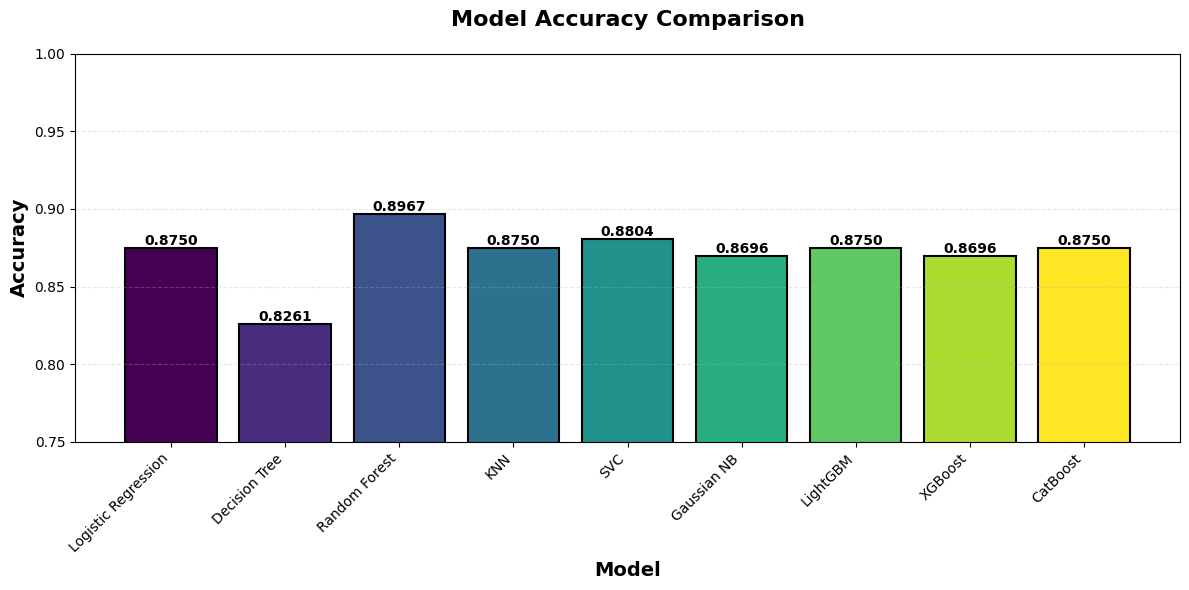

In [14]:
# Visualize Accuracy Comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

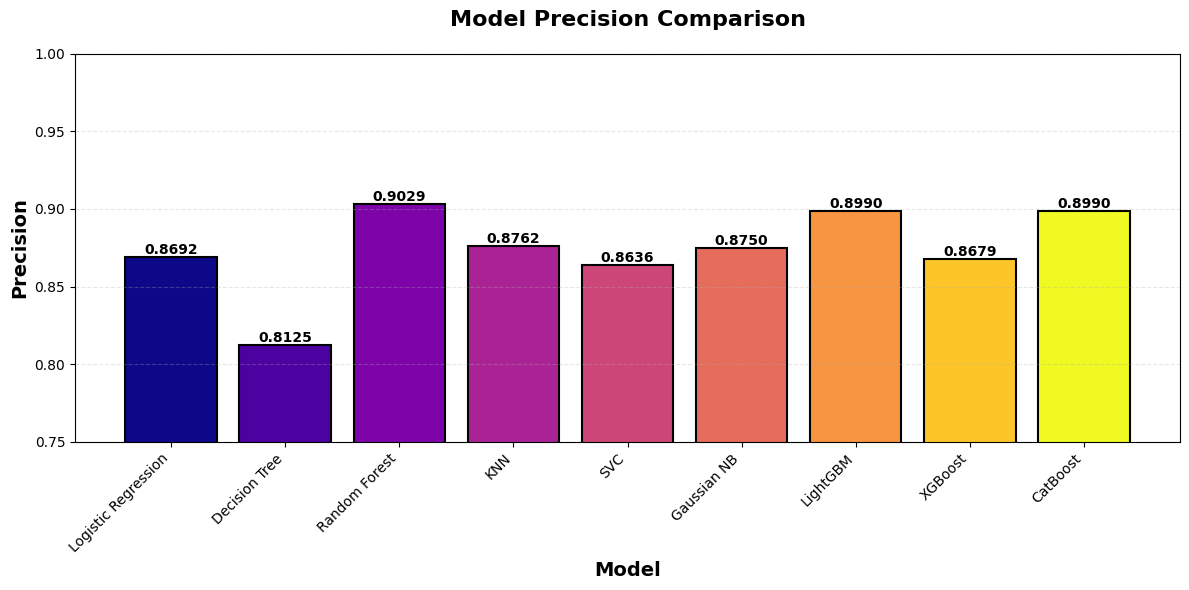

In [15]:
# Visualize Precision Comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(results_df)))
bars = plt.bar(results_df['Model'], results_df['Precision'], color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Model Precision Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

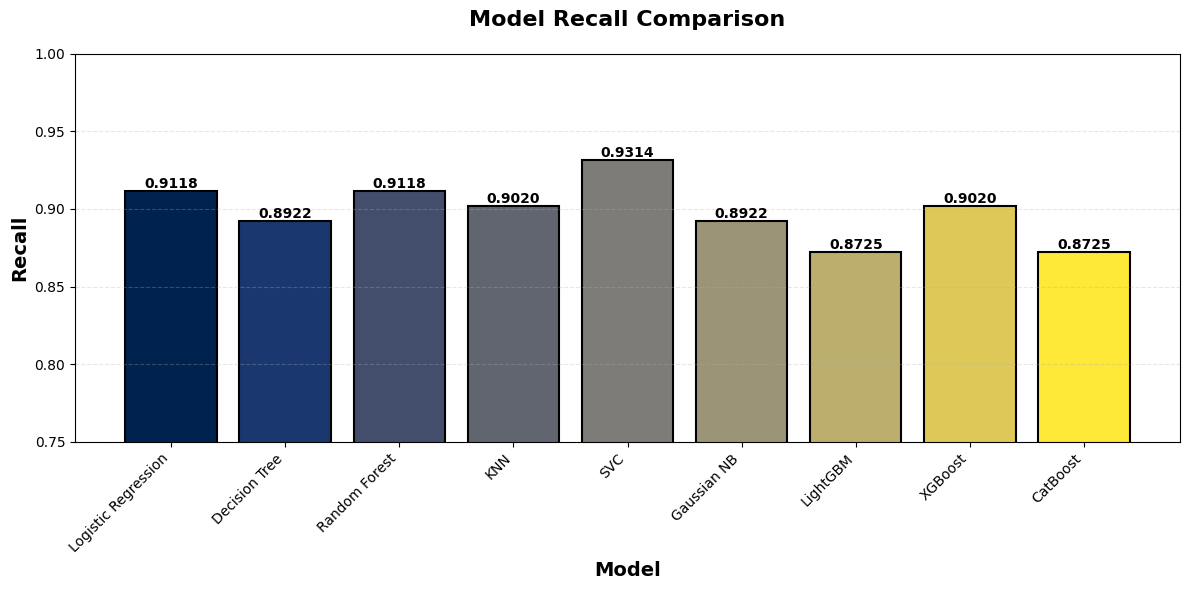

In [16]:
# Visualize Recall Comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.cividis(np.linspace(0, 1, len(results_df)))
bars = plt.bar(results_df['Model'], results_df['Recall'], color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Recall', fontsize=14, fontweight='bold')
plt.title('Model Recall Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

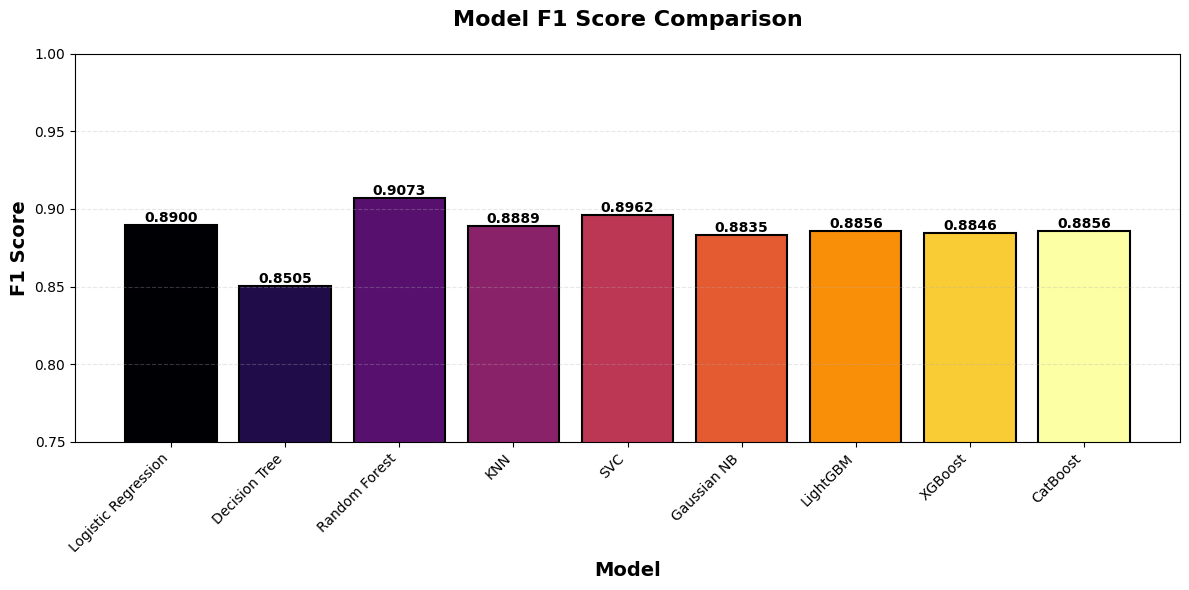

In [17]:
# Visualize F1 Score Comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.inferno(np.linspace(0, 1, len(results_df)))
bars = plt.bar(results_df['Model'], results_df['F1 Score'], color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score', fontsize=14, fontweight='bold')
plt.title('Model F1 Score Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

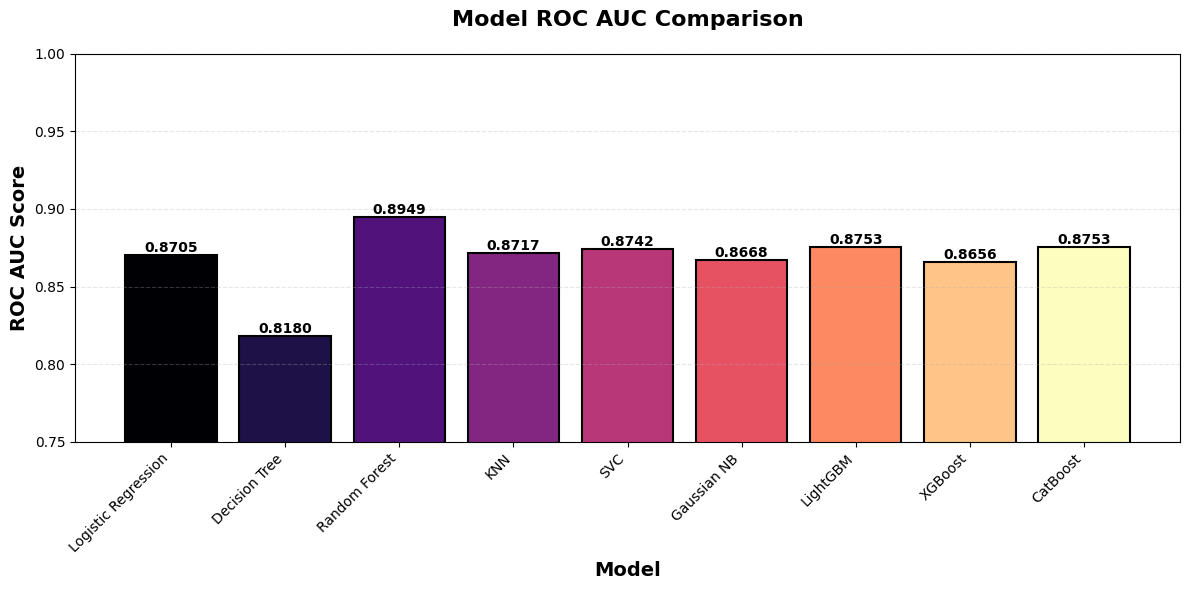

In [18]:
# Visualize ROC AUC Comparison
plt.figure(figsize=(12, 6))
colors = plt.cm.magma(np.linspace(0, 1, len(results_df)))
bars = plt.bar(results_df['Model'], results_df['ROC AUC'], color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('ROC AUC Score', fontsize=14, fontweight='bold')
plt.title('Model ROC AUC Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim([0.75, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

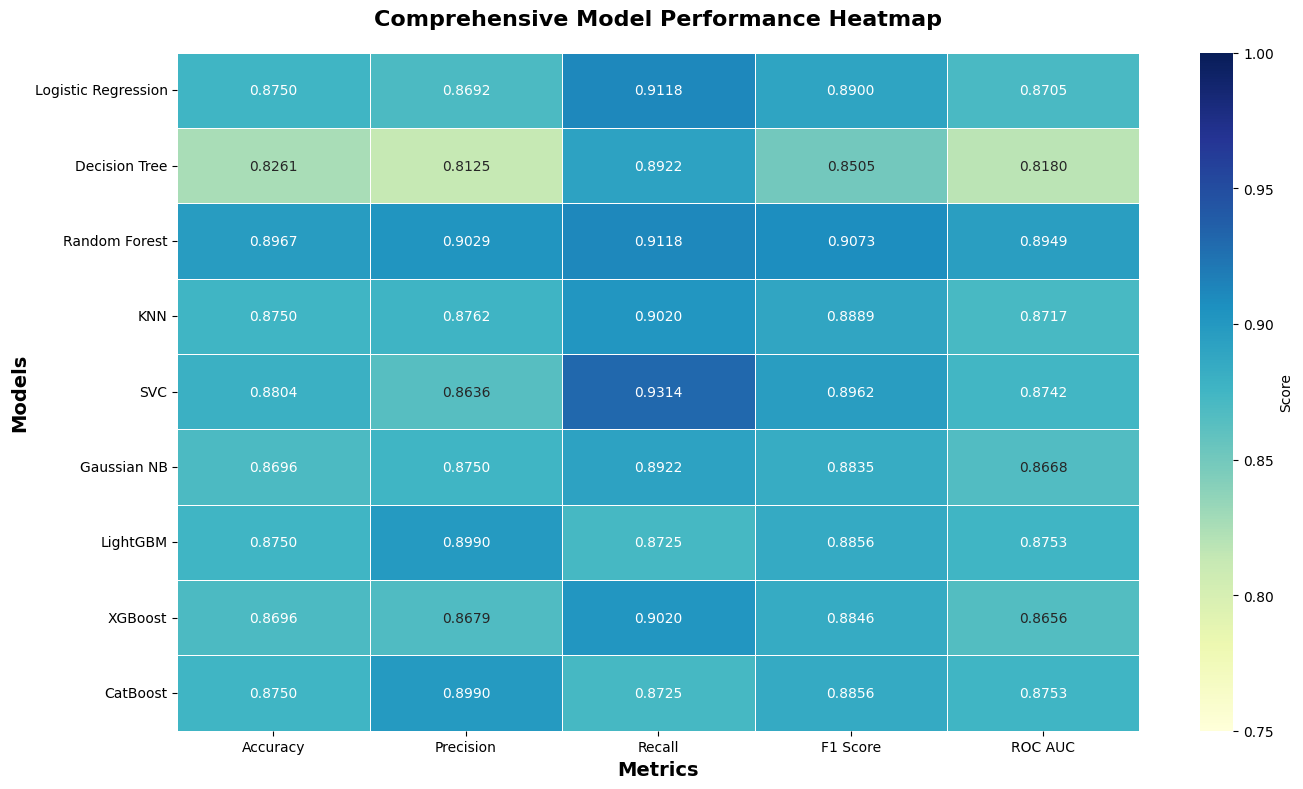

In [19]:
# Comprehensive Metrics Heatmap
plt.figure(figsize=(14, 8))

# Prepare data for heatmap (transpose for better visualization)
heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']]

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu', 
            linewidths=0.5, cbar_kws={'label': 'Score'}, 
            vmin=0.75, vmax=1.0)

plt.title('Comprehensive Model Performance Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Models', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

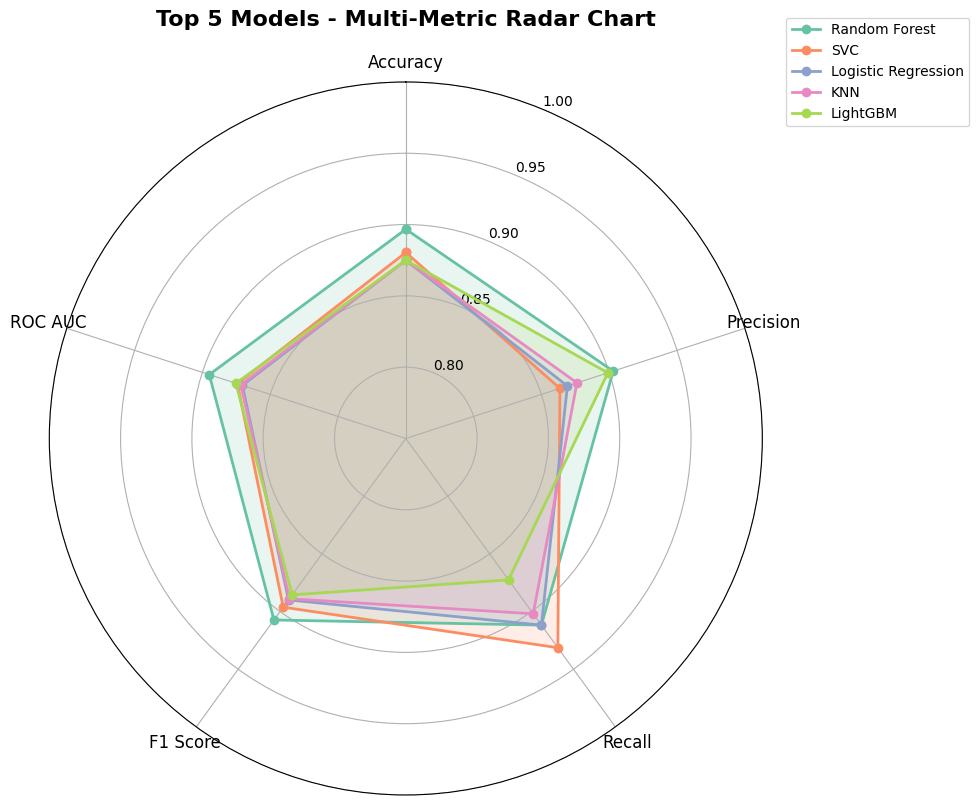

In [20]:
# Radar Chart for Multi-Metric Comparison (Top 5 Models by F1 Score)
from math import pi

# Select top 5 models by F1 Score
top_5_models = results_df.nlargest(5, 'F1 Score')

# Number of metrics
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
N = len(categories)

# Create figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Plot each model
colors_radar = plt.cm.Set2(range(len(top_5_models)))
for idx, (_, row) in enumerate(top_5_models.iterrows()):
    values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1 Score'], row['ROC AUC']]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

# Fix axis to go in the right order and start at 12 o'clock
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)

# Set y-axis limits
ax.set_ylim(0.75, 1.0)
ax.set_yticks([0.80, 0.85, 0.90, 0.95, 1.0])
ax.set_yticklabels(['0.80', '0.85', '0.90', '0.95', '1.00'])

# Add legend and title
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.title('Top 5 Models - Multi-Metric Radar Chart', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

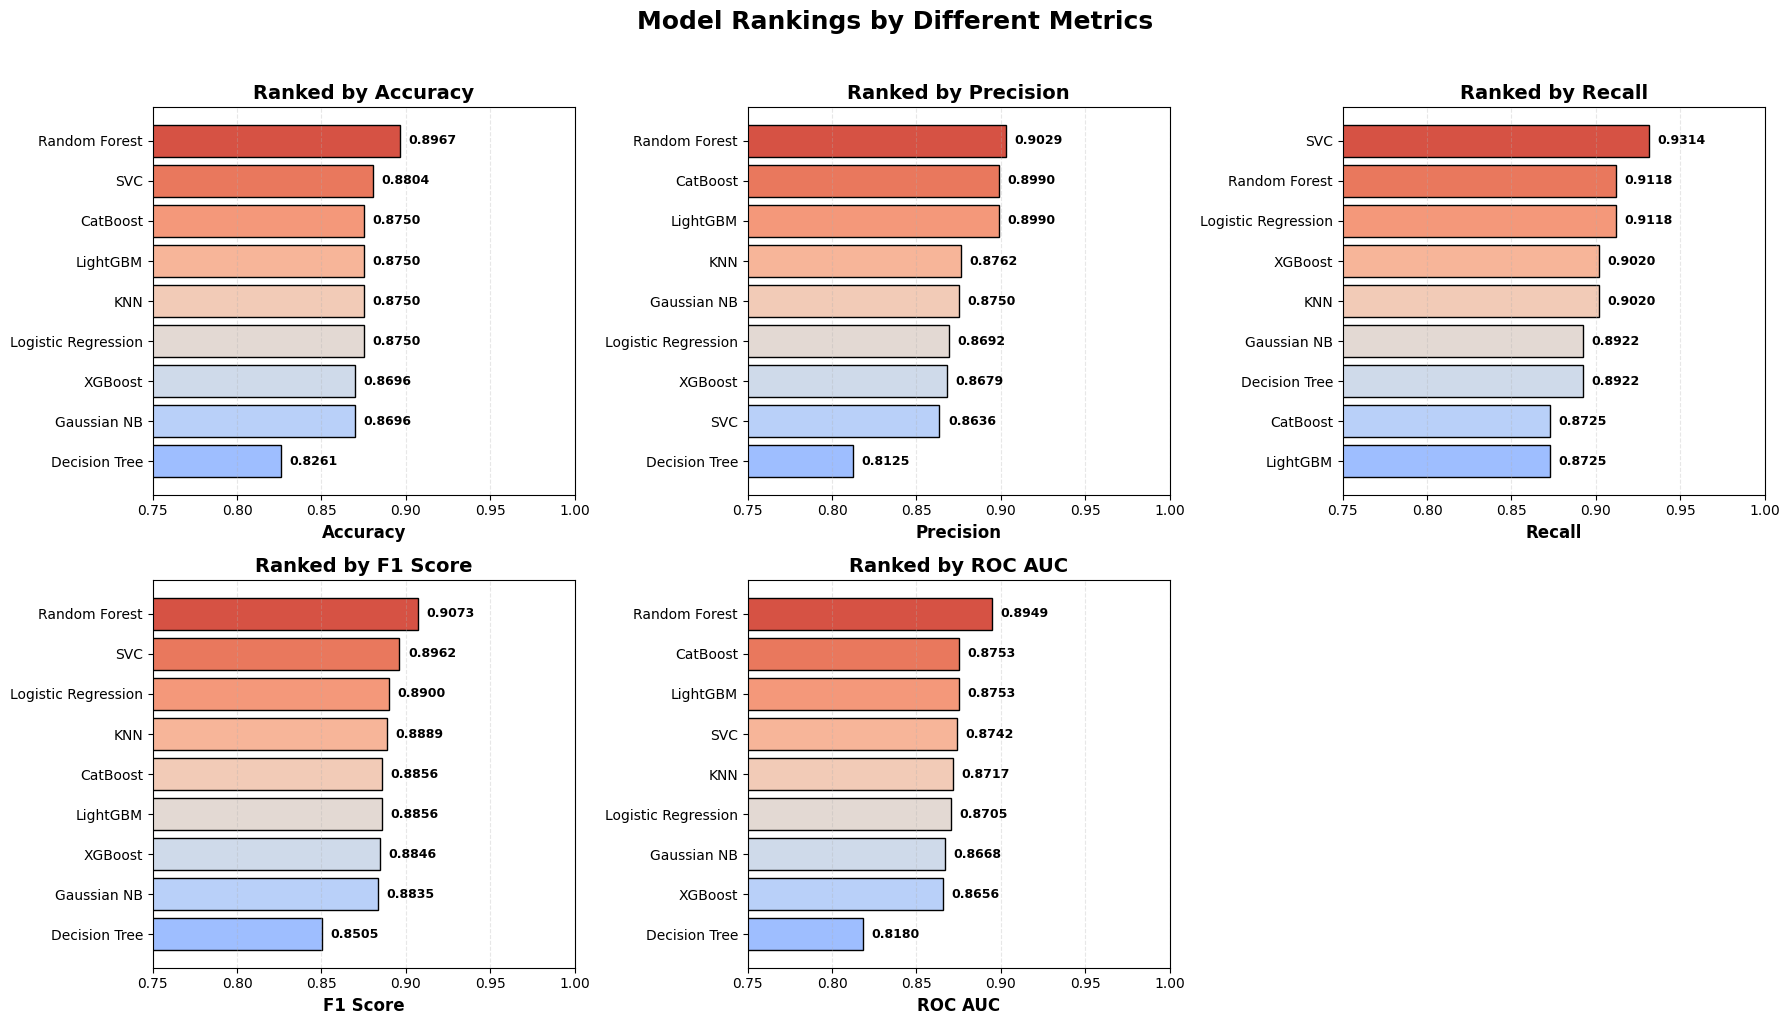

In [21]:
# Model Ranking by Different Metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Rankings by Different Metrics', fontsize=18, fontweight='bold', y=1.02)

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Sort by metric
    sorted_df = results_df.sort_values(metric, ascending=True)
    
    # Create horizontal bar chart
    colors_rank = plt.cm.coolwarm(np.linspace(0.3, 0.9, len(sorted_df)))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors_rank, edgecolor='black')
    
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'Ranked by {metric}', fontsize=14, fontweight='bold')
    ax.set_xlim([0.75, 1.0])
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2.,
                f'{width:.4f}',
                ha='left', va='center', fontsize=9, fontweight='bold')

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Best Model Summary
print("="*80)
print("BEST PERFORMING MODELS")
print("="*80)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"\nBest {metric:12s}: {best_model:20s} ({best_score:.4f})")

# Overall best model (by F1 Score)
best_overall_idx = results_df['F1 Score'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'Model']
print("\n" + "="*80)
print(f"RECOMMENDED MODEL (Highest F1 Score): {best_overall_model}")
print("="*80)
print("\nFull metrics for recommended model:")
print(results_df.loc[best_overall_idx].to_string())

BEST PERFORMING MODELS

Best Accuracy    : Random Forest        (0.8967)

Best Precision   : Random Forest        (0.9029)

Best Recall      : SVC                  (0.9314)

Best F1 Score    : Random Forest        (0.9073)

Best ROC AUC     : Random Forest        (0.8949)

RECOMMENDED MODEL (Highest F1 Score): Random Forest

Full metrics for recommended model:
Model        Random Forest
Accuracy          0.896739
Precision         0.902913
Recall            0.911765
F1 Score          0.907317
ROC AUC           0.894907
